In [1]:
import pandas as pd

file_csv = "/gpfs/home/memmelma/projects/LaMer/wandb_export_2026-03-24T10_43_45.727-07_00.csv"
df = pd.read_csv(file_csv)
df.head()

,step,env_id,reward,trajectory,env_info,won
0,1,1,"[1.0, 0, 0]",\n#### Environment Internal State ####\n[skipp...,"{'skipped_step_after_done': True, 'is_action_v...",True
1,1,2,"[1.0, 0, 0]",\n#### Environment Internal State ####\n[skipp...,"{'skipped_step_after_done': True, 'is_action_v...",True
2,1,3,"[1.0, 0, 0]",\n#### Environment Internal State ####\n[skipp...,"{'skipped_step_after_done': True, 'is_action_v...",True
3,1,4,"[1.0, 0, 0]",\n#### Environment Internal State ####\n[skipp...,"{'skipped_step_after_done': True, 'is_action_v...",True
4,1,5,"[1.0, 0, 0]",\n#### Environment Internal State ####\n[skipp...,"{'skipped_step_after_done': True, 'is_action_v...",True


In [7]:
import re
import wandb
import numpy as np
import pandas as pd

api = wandb.Api()
run = api.run("memmelma/lamer/8zh4gsbv")

training_arts = []
for art in run.logged_artifacts():
    if "trainingcot_trajectory" in art.name:
        version = int(re.search(r':v(\d+)$', art.name).group(1))
        training_arts.append((version, art))

# Sort by version and pick the highest
training_arts.sort(key=lambda x: x[0])

latest_art = training_arts[-1][1]
print(f"Using: {latest_art.name}")

table = latest_art.get("training/cot_trajectory")
df = pd.DataFrame(data=table.data, columns=table.columns)
print(df.shape)

Using: run-8zh4gsbv-trainingcot_trajectory-gwV5fw:v14


wandb:   1 of 1 files downloaded.  


(240, 6)


In [8]:
for i in range(1, 16):
    for j in range(16):
        task = df[df["step"] == i]["trajectory"].iloc[j].split("Task: ")[-1].split("\n")[0]
        print("step", i, "env_id", j, "task", task)


step 1 env_id 0 task group each color into its own corner: red blocks to the upper left corner, blue blocks to the top right corner, green blocks to the lower left corner, and yellow blocks to the bottom right corner
step 1 env_id 1 task sort all blocks by color into the corners: red blocks to the top left, blue blocks to the top right corner, green blocks to the bottom left corner, and yellow blocks to the bottom right
step 1 env_id 2 task organize the blocks so each corner has one color: red blocks to the top left, blue blocks to the top right, green blocks to the bottom left corner, and yellow blocks to the bottom right
step 1 env_id 3 task group each color into its own corner: red blocks to the top left corner, blue blocks to the top right corner, green blocks to the lower left corner, and yellow blocks to the bottom right corner
step 1 env_id 4 task organize the blocks so each corner has one color: red blocks to the top left corner, blue blocks to the top right corner, green block

In [9]:
step_idx = 3  # change to whichever step you want

step_df = df[df["step"] == step_idx]
for _, row in step_df.iterrows():
    # print(f"===== env_id: {row['env_id']} | step: {step_idx} =====")
    # print(row["trajectory"])
    # print()

    if ast.literal_eval(str(row["reward"])) == [0.0, 0.0, 0.0]:
        traj = row["trajectory"]
        matches = re.findall(
            r"<action>(.*?)</action>", traj, re.DOTALL
        )
    if matches:
        extracted = matches[-1].strip()
        print(matches)

NameError: name 'ast' is not defined

In [10]:
import re
for i in range(1, np.max(df["step"])):
    traj = df[df["step"] == i]["trajectory"].iloc[0]
    matches = re.findall(
        r"<action>(.*?)</action>", traj, re.DOTALL
    )
    if matches:
        extracted = matches[-1].strip()
        print(extracted)

push the red moon to the upper left corner
Move the red moon to the top left.
move the red_moon to the top-left corner
Move the blue cube to the top left corner.
Move the yellow pentagon to the bottom right corner.
Move the green star to the bottom right corner.
Move the red moon to the lower left corner.
move the end-effector to the center of the table and push the red moon to the upper left corner, the blue cube to the top right corner, the green star to the bottom left corner, and the yellow pentagon to the bottom right corner
Move to the top left corner and push the red_moon there
Push the red moon to the top left corner
push the red moon to the upper left corner, push the blue cube to the upper right corner, push the green star to the lower left corner, push the yellow pentagon to the lower right corner
move the green star to the bottom left of the table
push the red_moon to the upper left corner, the blue_cube to the top right corner, the green_star to the bottom left corner, and

<Axes: >

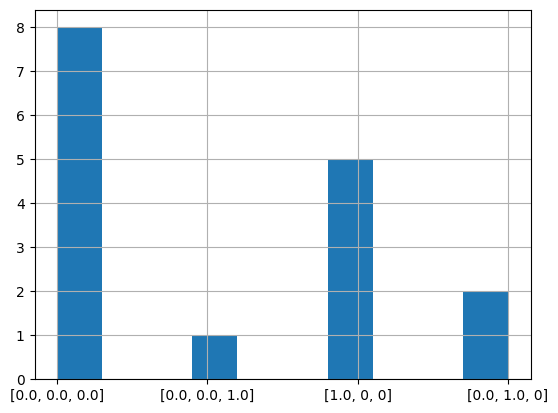

In [5]:
df[df["step"] == 256]["reward"].hist()

In [ ]:
sum_arrays = []
for i in range(1, np.max(df["step"])):
    rewards = df[df["step"] == i]["reward"].apply(lambda x: np.array(ast.literal_eval(str(x))))
    sum_array = rewards.sum()
    sum_arrays.append(sum_array)
sum_arrays = np.array(sum_arrays)

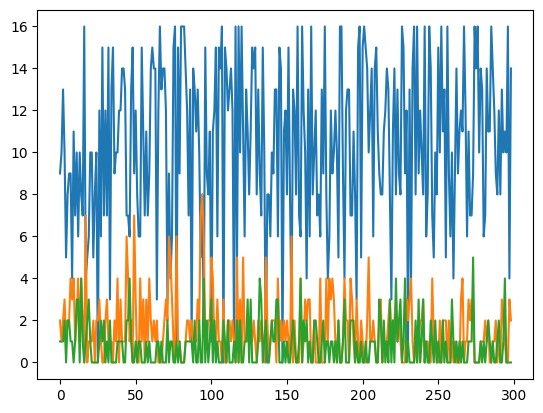

In [ ]:
import ast
import numpy as np
import matplotlib.pyplot as plt

sum_arrays = []
for i in range(1, np.max(df["step"])):
    rewards = df[df["step"] == i]["reward"].apply(lambda x: np.array(ast.literal_eval(str(x))))
    sum_array = rewards.sum()
    sum_arrays.append(sum_array)
sum_arrays = np.array(sum_arrays)

plt.plot(sum_arrays)

In [11]:
rewards

4080    [0.0, 0.0, 0.0]
4081    [0.0, 0.0, 0.0]
4082    [0.0, 0.0, 0.0]
4083    [0.0, 0.0, 0.0]
4084    [0.0, 0.0, 0.0]
4085    [0.0, 0.0, 1.0]
4086    [0.0, 0.0, 0.0]
4087    [0.0, 0.0, 0.0]
4088    [1.0, 0.0, 0.0]
4089    [1.0, 0.0, 0.0]
4090    [0.0, 1.0, 0.0]
4091    [1.0, 0.0, 0.0]
4092    [1.0, 0.0, 0.0]
4093    [1.0, 0.0, 0.0]
4094    [0.0, 0.0, 0.0]
4095    [0.0, 1.0, 0.0]
Name: reward, dtype: object

<Axes: >

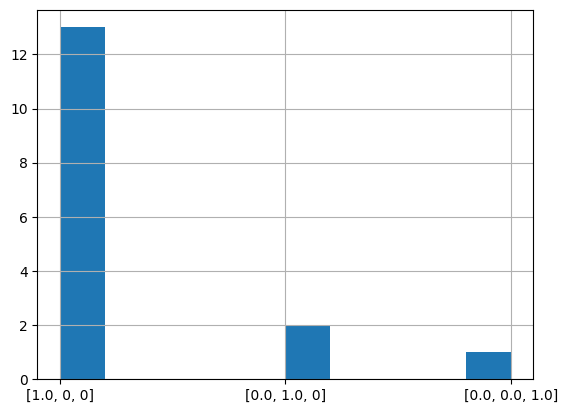

In [36]:
df[df["step"] == 1]["reward"].hist()

In [18]:
import numpy as np

actions_per_trial = []
import ast

# Convert the reward column from string to list of floats
df['reward_list'] = df['reward'].apply(lambda x: ast.literal_eval(str(x)))
# success_reward = [0.0, 0.0, 1.0]
# success_reward = [0.0, 1.0, 0.0]
success_reward = [1.0, 0.0, 0.0]
df_success = df[df['reward_list'].apply(lambda x: x == success_reward)]['trajectory']
for i in range(len(df_success)):

    response = df_success.iloc[i]
    # print(response)

    # find all strings between <action> and </action> tags
    import re
    action_pattern = re.compile(r'<action>(.*?)</action>', re.DOTALL)
    actions = action_pattern.findall(response)
    actions = [a for a in actions if a != ' ']
    actions_per_trial.append(actions)

In [19]:
len(actions_per_trial)

1387

In [7]:
['Move the yellow pentagon to be next to the red moon',
'Move the yellow pentagon to (0.439, 0.124)',
'Move the yellow pentagon to (0.439, 0.124)',

'Push the yellow pentagon to the right and up to the position of the red moon.',
'Push the yellow pentagon to the right and up so that it is directly next to the red moon.'
'Push the yellow pentagon to the right and up so that it is directly next to the red moon.',

'Push the yellow pentagon to the right and up so that it is directly adjacent to the red moon.',
'Push the yellow pentagon to the left and up so that it is directly adjacent to the red moon.',
'Push the yellow pentagon to the right and up so that it is directly above the red moon.']


['Move the yellow pentagon to be next to the red moon',
 'Move the yellow pentagon to (0.439, 0.124)',
 'Move the yellow pentagon to (0.439, 0.124)',
 'Push the yellow pentagon to the right and up to the position of the red moon.',
 'Push the yellow pentagon to the right and up so that it is directly next to the red moon.Push the yellow pentagon to the right and up so that it is directly next to the red moon.',
 'Push the yellow pentagon to the right and up so that it is directly adjacent to the red moon.',
 'Push the yellow pentagon to the left and up so that it is directly adjacent to the red moon.',
 'Push the yellow pentagon to the right and up so that it is directly above the red moon.']